In [11]:
# ==== Notebook setup (must be at top of cell) ====
%matplotlib inline

import os
import json
import time
from dataclasses import dataclass
from typing import Tuple, Dict, Any, Optional, List

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display

import control as ct
from scipy.linalg import block_diag

import jax
import jax.numpy as jnp
import diffrax
from jax_sysid.models import CTModel


# =========================================================
# Plot helpers (INLINE + also optionally save)
# =========================================================
def voltage_plot_inline(
    t: np.ndarray,
    y: np.ndarray,
    yhat: Optional[np.ndarray] = None,
    title: str = "Voltage",
):
    """Show the plot inline in the notebook."""
    plt.figure(figsize=(10, 4))
    plt.plot(t, y[:, 0], label="Truth")
    if yhat is not None:
        plt.plot(t, yhat[:, 0], "--", label="Pred")
    plt.grid(True)
    plt.legend()
    plt.xlabel("t [s]")
    plt.ylabel("V [V]")
    plt.title(title)
    ax = plt.gca()
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter(useOffset=False))
    ax.ticklabel_format(axis="y", style="plain", useOffset=False)
    plt.tight_layout()
    plt.show()


def save_voltage_plot(
    path: str,
    t: np.ndarray,
    y: np.ndarray,
    yhat: Optional[np.ndarray] = None,
    title: str = "Voltage",
):
    """Save plot to disk (png)."""
    plt.figure(figsize=(10, 4))
    plt.plot(t, y[:, 0], label="Truth")
    if yhat is not None:
        plt.plot(t, yhat[:, 0], "--", label="Pred")
    plt.grid(True)
    plt.legend()
    plt.xlabel("t [s]")
    plt.ylabel("V [V]")
    plt.title(title)
    ax = plt.gca()
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter(useOffset=False))
    ax.ticklabel_format(axis="y", style="plain", useOffset=False)
    plt.tight_layout()
    plt.savefig(path, dpi=200)
    plt.close()


# =========================================================
# Config
# =========================================================
@dataclass
class Config:
    # Physical constants
    R: float = 8.314462618
    F: float = 96485.33212
    T: float = 298.15
    T_ref: float = 298.15

    # Geometry
    L1: float = 25e-6
    L2: float = 20e-6
    L3: float = 25e-6
    Rn: float = 5e-6
    Rp: float = 5e-6
    A: float = 1.0

    # Transport
    Dn: float = 1e-14
    Dp: float = 1e-14
    De: float = 7.23e-10
    eps: float = 0.30

    # Effective conductivities for R_el
    kappa_n_eff: float = 1.0
    kappa_s_eff: float = 1.0
    kappa_p_eff: float = 1.0

    # Kinetics / active surface
    a_s_n: float = 1.0e6
    a_s_p: float = 1.0e6
    k_n0: float = 2.0e-11
    k_p0: float = 2.0e-11
    use_arrhenius: bool = False
    Ea_n: float = 0.0
    Ea_p: float = 0.0

    # LAM (optional)
    lam_n: float = 0.0
    lam_p: float = 0.0

    # Capacity-scale (stoichiometries)
    csn_max: float = 3.1e4
    csp_max: float = 3.1e4

    # Electrolyte & electrical
    ce0: float = 1000.0
    t_plus: float = 0.38
    k_f: float = 1.0
    R_ohm: float = 0.0
    use_dynamic_film: bool = False
    Rf: float = 0.0
    L_sei: float = 0.0
    kappa_sei: float = 1.0

    # Flags & conventions
    ce_is_deviation: bool = True
    discharge_positive: bool = True
    ln_orientation: str = "right_over_left"
    eta_mode: str = "diff"

    # Numerical guards / stability
    theta_guard: float = 1e-3
    bv_scale: float = 0.7
    N_series: int = 3

    # Discretization sizes
    Nn: int = 16
    Np: int = 16
    Ne_n: int = 8
    Ne_s: int = 8
    Ne_p: int = 8


# =========================================================
# OCVs
# =========================================================
def ocp_p(xp: np.ndarray) -> np.ndarray:
    x = np.clip(xp, 1e-9, 1 - 1e-9)
    return 4.15 - 0.12 * np.tanh((x - 0.60) / 0.08)

def ocp_n(xn: np.ndarray) -> np.ndarray:
    x = np.clip(xn, 1e-9, 1 - 1e-9)
    return 0.10 + 0.80 * (1.0 / (1.0 + np.exp(-(x - 0.50) / 0.04)))


# =========================================================
# Dynamic index map for arbitrary N
# =========================================================
def make_idx(cfg: Config) -> Dict[str, Any]:
    Nn = int(cfg.Nn)
    Np = int(cfg.Np)
    Ne = int(cfg.Ne_n + cfg.Ne_s + cfg.Ne_p)
    off_cp = Nn
    off_ce = Nn + Np

    return dict(
        Nn=Nn, Np=Np, Ne=Ne, nx=Nn+Np+Ne,
        cn=slice(0, Nn),
        cp=slice(off_cp, off_cp+Np),
        ce=slice(off_ce, off_ce+Ne),
        cn_surf=Nn-1,
        cp_surf=off_cp + (Np-1),
        ce_left=off_ce + 0,
        ce_right=off_ce + (Ne-1),
    )


# =========================================================
# Generic FVM builders
# =========================================================
def build_solid_fvm(N: int, D: float, R: float) -> np.ndarray:
    s = D / (R**2)
    A = np.zeros((N, N))
    for i in range(1, N-1):
        A[i, i-1] = 1.0
        A[i, i]   = -2.0
        A[i, i+1] = 1.0
    A[0, 0] = -1.0
    A[0, 1] =  1.0
    A[N-1, N-2] = 1.0
    A[N-1, N-1] = -1.0
    return s * A


def build_solid_input(N: int, cfg: Config, electrode: str) -> np.ndarray:
    b = np.zeros((N, 1))
    if electrode == "n":
        sign = -1.0 if cfg.discharge_positive else +1.0
        coef = sign * (6.0 / cfg.Rn) * (1.0 / (cfg.F * cfg.a_s_n * cfg.A * cfg.L1))
    elif electrode == "p":
        sign = +1.0 if cfg.discharge_positive else -1.0
        coef = sign * (6.0 / cfg.Rp) * (1.0 / (cfg.F * cfg.a_s_p * cfg.A * cfg.L3))
    else:
        raise ValueError("electrode must be 'n' or 'p'")
    b[-1, 0] = coef
    return b


def build_electrolyte_1d(Nn: int, Ns: int, Np: int, cfg: Config) -> Tuple[np.ndarray, np.ndarray]:
    Ne = Nn + Ns + Np
    K = cfg.De / cfg.eps

    Ln, Ls, Lp = cfg.L1, cfg.L2, cfg.L3
    dx_n = Ln / Nn
    dx_s = Ls / Ns
    dx_p = Lp / Np

    A = np.zeros((Ne, Ne))

    def dx(i: int) -> float:
        if i < Nn:
            return dx_n
        if i < Nn + Ns:
            return dx_s
        return dx_p

    for i in range(Ne):
        if i > 0:
            dxL = dx(i-1)
            dxi = dx(i)
            wL = K / (0.5*(dxL+dxi)**2)
            A[i, i]   -= wL
            A[i, i-1] += wL
        if i < Ne-1:
            dxi = dx(i)
            dxR = dx(i+1)
            wR = K / (0.5*(dxi+dxR)**2)
            A[i, i]   -= wR
            A[i, i+1] += wR

    b = np.zeros((Ne, 1))
    sign_left  = -1.0 if cfg.discharge_positive else +1.0
    sign_right = +1.0 if cfg.discharge_positive else -1.0

    s1 = sign_left  * (1.0 - cfg.t_plus) / (cfg.F * cfg.A * cfg.L1 * cfg.eps)
    s3 = sign_right * (1.0 - cfg.t_plus) / (cfg.F * cfg.A * cfg.L3 * cfg.eps)

    b[0, 0] = s1
    if Nn > 1:
        b[1, 0] = s1
    b[-1, 0] = s3
    if Np > 1:
        b[-2, 0] = s3

    return A, b


# =========================================================
# Assemble system
# =========================================================
def assemble_system(cfg: Config):
    idx = make_idx(cfg)

    An = build_solid_fvm(idx["Nn"], cfg.Dn, cfg.Rn)
    Ap = build_solid_fvm(idx["Np"], cfg.Dp, cfg.Rp)
    Bn = build_solid_input(idx["Nn"], cfg, electrode="n")
    Bp = build_solid_input(idx["Np"], cfg, electrode="p")

    Ae, Be = build_electrolyte_1d(cfg.Ne_n, cfg.Ne_s, cfg.Ne_p, cfg)

    Aglob = block_diag(An, Ap, Ae)
    Bglob = np.vstack([Bn, Bp, Be])

    state_names = (
        [f"cn{i}" for i in range(1, idx["Nn"] + 1)]
        + [f"cp{i}" for i in range(1, idx["Np"] + 1)]
        + [f"ce{i}" for i in range(1, idx["Ne"] + 1)]
    )

    S = ct.ss(Aglob, Bglob, np.eye(Aglob.shape[0]), np.zeros((Aglob.shape[0], 1)))
    blocks = (An, Ap, Ae, Bn, Bp, Be)
    return S, Aglob, Bglob, blocks, state_names, idx


def make_x0(cfg: Config, idx: Dict[str, Any], theta_n0=0.8, theta_p0=0.4, ce0=0.0):
    x0 = np.zeros(idx["nx"], dtype=np.float64)
    x0[idx["cn"]] = float(theta_n0) * cfg.csn_max
    x0[idx["cp"]] = float(theta_p0) * cfg.csp_max
    x0[idx["ce"]] = float(ce0)
    return x0


# =========================================================
# Voltage terms
# =========================================================
def electrolyte_resistance(cfg: Config) -> float:
    return (cfg.L1 / cfg.kappa_n_eff + 2.0 * cfg.L2 / cfg.kappa_s_eff + cfg.L3 / cfg.kappa_p_eff) / (2.0 * cfg.A)

def film_resistance(cfg: Config) -> float:
    if cfg.use_dynamic_film and cfg.L_sei > 0.0:
        return cfg.L_sei / (cfg.kappa_sei * cfg.a_s_n * cfg.A * cfg.L1)
    return cfg.Rf


# =========================================================
# Synthetic truth generator
# =========================================================
def terminal_voltage_truth(x: np.ndarray, cfg: Config, idx: Dict[str, Any], I: float) -> float:
    xp = np.clip(x[idx["cp_surf"]] / cfg.csp_max, 1e-9, 1 - 1e-9)
    xn = np.clip(x[idx["cn_surf"]] / cfg.csn_max, 1e-9, 1 - 1e-9)
    Up = float(ocp_p(np.array([xp]))[0])
    Un = float(ocp_n(np.array([xn]))[0])

    ceL_raw = float(x[idx["ce_left"]])
    ceR_raw = float(x[idx["ce_right"]])
    ceL = (cfg.ce0 + ceL_raw) if cfg.ce_is_deviation else ceL_raw
    ceR = (cfg.ce0 + ceR_raw) if cfg.ce_is_deviation else ceR_raw
    ceL = max(ceL, 1e-12)
    ceR = max(ceR, 1e-12)

    kappa = (2.0 * cfg.R * cfg.T / cfg.F)
    eta_combo = cfg.bv_scale * kappa * np.arcsinh(I / (2.0 * 1.0))

    ln_arg = (ceR / ceL) if (cfg.ln_orientation == "right_over_left") else (ceL / ceR)
    Ke_phys = (2.0 * cfg.R * cfg.T / cfg.F) * (1.0 - cfg.t_plus) * cfg.k_f
    dphi_e = Ke_phys * np.log(max(ln_arg, 1e-12))

    ohmic = -I * (cfg.R_ohm + electrolyte_resistance(cfg) + film_resistance(cfg))
    V_cell = (Up - Un) + eta_combo + dphi_e + ohmic
    return float(cfg.N_series * V_cell)


def battery_update(t, x, u, params):
    A = params["A"]; B = params["B"]
    if u is None or (hasattr(u, "size") and u.size == 0):
        I = float(params["I_const"])
    else:
        I = float(np.asarray(u).reshape(-1)[0])
    return A @ x + B[:, 0] * I


def battery_output(t, x, u, params):
    cfg = params["cfg"]
    idx = params["idx"]
    if u is None or (hasattr(u, "size") and u.size == 0):
        I = float(params["I_const"])
    else:
        I = float(np.asarray(u).reshape(-1)[0])
    V = terminal_voltage_truth(x, cfg, idx, I=I)
    return np.hstack([x, V])


def generate_discharge_data(
    cfg: Config,
    *,
    I_const: float,
    sim_t_end: float,
    sim_dt: float,
    theta_n0: float,
    theta_p0: float,
    ce0: float,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, Dict[str, Any]]:
    T = np.arange(0.0, sim_t_end + sim_dt, sim_dt)

    _, A, B, _, state_names, idx = assemble_system(cfg)
    nl_params = dict(A=A, B=B, cfg=cfg, idx=idx, I_const=float(I_const))

    battery_nl = ct.nlsys(
        battery_update, battery_output,
        name="battery_synth",
        params=nl_params,
        states=state_names,
        outputs=state_names + ["V"],
        inputs=0,
    )

    x0 = make_x0(cfg, idx, theta_n0=theta_n0, theta_p0=theta_p0, ce0=ce0)
    resp = ct.input_output_response(battery_nl, T, 0, X0=x0)

    X = resp.states.T
    Y_full = resp.outputs.T
    V = Y_full[:, -1:].copy()
    U = np.full((len(T), 1), float(I_const), dtype=np.float64)

    return T.astype(np.float64), U.astype(np.float64), X.astype(np.float64), V.astype(np.float64), idx


# =========================================================
# JAX models (Stage2 + Stage4)
# =========================================================
def build_stage2_and_stage4_models(cfg: Config, idx: Dict[str, Any], theta_guard: float, use_v0: bool):
    jax.config.update("jax_platform_name", "cpu")
    jax.config.update("jax_enable_x64", True)
    DTYPE = jnp.float64

    _, A_np, B_np, (An_np, Ap_np, Ae_np, Bn_np, Bp_np, Be_np), _, _ = assemble_system(cfg)
    A_fix = jnp.array(A_np, dtype=DTYPE)
    B_fix = jnp.array(B_np, dtype=DTYPE)

    An0 = jnp.array(An_np, dtype=DTYPE)
    Ap0 = jnp.array(Ap_np, dtype=DTYPE)
    Ae0 = jnp.array(Ae_np, dtype=DTYPE)
    Bn0 = jnp.array(Bn_np, dtype=DTYPE)
    Bp0 = jnp.array(Bp_np, dtype=DTYPE)
    Be0 = jnp.array(Be_np, dtype=DTYPE)

    R_fixed = float(cfg.R_ohm + electrolyte_resistance(cfg) + film_resistance(cfg))

    @jax.jit
    def ocp_p_jax(xp):
        xp = jnp.clip(xp, 1e-9, 1 - 1e-9)
        return 4.15 - 0.12 * jnp.tanh((xp - 0.60) / 0.08)

    @jax.jit
    def ocp_n_jax(xn):
        xn = jnp.clip(xn, 1e-9, 1 - 1e-9)
        return 0.10 + 0.80 * (1.0 / (1.0 + jnp.exp(-(xn - 0.50) / 0.04)))

    def theta_map(raw_theta: jnp.ndarray) -> dict:
        Gamma_p = jnp.exp(raw_theta[0])
        Gamma_n = jnp.exp(raw_theta[1])
        K_e     = jnp.exp(raw_theta[2])
        R0      = jnp.exp(raw_theta[3])
        V0      = raw_theta[4] if use_v0 else DTYPE(0.0)
        return dict(
            csn_max=DTYPE(cfg.csn_max),
            csp_max=DTYPE(cfg.csp_max),
            Gamma_p=Gamma_p,
            Gamma_n=Gamma_n,
            K_e=K_e,
            R0=R0,
            V0=V0,
        )

    def voltage_from_params(x, I, p: dict):
        xp = jnp.clip(x[idx["cp_surf"]] / p["csp_max"], 1e-9, 1 - 1e-9)
        xn = jnp.clip(x[idx["cn_surf"]] / p["csn_max"], 1e-9, 1 - 1e-9)

        Up = ocp_p_jax(xp)
        Un = ocp_n_jax(xn)

        ceL_raw = x[idx["ce_left"]]
        ceR_raw = x[idx["ce_right"]]
        ceL = (DTYPE(cfg.ce0) + ceL_raw) if cfg.ce_is_deviation else ceL_raw
        ceR = (DTYPE(cfg.ce0) + ceR_raw) if cfg.ce_is_deviation else ceR_raw
        ceL = jnp.maximum(ceL, 1e-12)
        ceR = jnp.maximum(ceR, 1e-12)
        ce_avg = jnp.clip(0.5 * (ceL + ceR), 1e-12, 1e12)

        xp_eff = jnp.clip(xp, theta_guard, 1.0 - theta_guard)
        xn_eff = jnp.clip(xn, theta_guard, 1.0 - theta_guard)

        denom_p = p["Gamma_p"] * jnp.sqrt(ce_avg) * jnp.sqrt(xp_eff * (1 - xp_eff)) + 1e-18
        denom_n = p["Gamma_n"] * jnp.sqrt(ce_avg) * jnp.sqrt(xn_eff * (1 - xn_eff)) + 1e-18

        kappa = (2.0 * DTYPE(cfg.R) * DTYPE(cfg.T) / DTYPE(cfg.F))
        eta_p = DTYPE(cfg.bv_scale) * kappa * jnp.arcsinh(I / (2.0 * denom_p))
        eta_n = DTYPE(cfg.bv_scale) * kappa * jnp.arcsinh(I / (2.0 * denom_n))
        eta_combo = (eta_p - eta_n) if (cfg.eta_mode == "diff") else (eta_p + eta_n)

        ln_arg = (ceR / ceL) if (cfg.ln_orientation == "right_over_left") else (ceL / ceR)
        dphi_e = p["K_e"] * jnp.log(jnp.maximum(ln_arg, 1e-12))

        ohmic = -I * (DTYPE(R_fixed) + p["R0"])
        V_cell = (Up - Un) + eta_combo + dphi_e + ohmic
        V = DTYPE(cfg.N_series) * V_cell + p["V0"]
        return V

    @jax.jit
    def state_fcn_stage2(x, u, t, params):
        I = u[0]
        return A_fix @ x + (B_fix[:, 0] * I)

    @jax.jit
    def output_fcn_stage2(x, u, t, params):
        (raw_theta,) = params
        p = theta_map(raw_theta)
        I = u[0]
        V = voltage_from_params(x, I, p)
        return jnp.array([V], dtype=DTYPE)

    def ab_map(raw_ab: jnp.ndarray) -> dict:
        return dict(
            sDn=jnp.exp(raw_ab[0]),
            sDp=jnp.exp(raw_ab[1]),
            sDe=jnp.exp(raw_ab[2]),
            gn=jnp.exp(raw_ab[3]),
            gp=jnp.exp(raw_ab[4]),
            ge=jnp.exp(raw_ab[5]),
        )

    def build_AB_from_ab(raw_ab: jnp.ndarray):
        ab = ab_map(raw_ab)
        A = jnp.block([
            [ab["sDn"] * An0,               jnp.zeros((An0.shape[0], Ap0.shape[1]), dtype=DTYPE), jnp.zeros((An0.shape[0], Ae0.shape[1]), dtype=DTYPE)],
            [jnp.zeros((Ap0.shape[0], An0.shape[1]), dtype=DTYPE), ab["sDp"] * Ap0,               jnp.zeros((Ap0.shape[0], Ae0.shape[1]), dtype=DTYPE)],
            [jnp.zeros((Ae0.shape[0], An0.shape[1]), dtype=DTYPE), jnp.zeros((Ae0.shape[0], Ap0.shape[1]), dtype=DTYPE), ab["sDe"] * Ae0],
        ])
        B = jnp.concatenate([ab["gn"] * Bn0, ab["gp"] * Bp0, ab["ge"] * Be0], axis=0)
        return A, B

    theta_len = 5 if use_v0 else 4

    def unpack_stage4(raw: jnp.ndarray):
        raw_theta = raw[:theta_len]
        raw_ab = raw[theta_len:theta_len + 6]
        return raw_theta, raw_ab

    @jax.jit
    def state_fcn_stage4(x, u, t, params):
        (raw,) = params
        _, raw_ab = unpack_stage4(raw)
        A, B = build_AB_from_ab(raw_ab)
        I = u[0]
        return A @ x + (B[:, 0] * I)

    @jax.jit
    def output_fcn_stage4(x, u, t, params):
        (raw,) = params
        raw_theta, _ = unpack_stage4(raw)
        p = theta_map(raw_theta)
        I = u[0]
        V = voltage_from_params(x, I, p)
        return jnp.array([V], dtype=DTYPE)

    return dict(
        DTYPE=DTYPE,
        theta_map=theta_map,
        ab_map=ab_map,
        state_fcn_stage2=state_fcn_stage2,
        output_fcn_stage2=output_fcn_stage2,
        state_fcn_stage4=state_fcn_stage4,
        output_fcn_stage4=output_fcn_stage4,
        R_fixed=R_fixed,
        theta_len=theta_len,
        nx=int(idx["nx"]),
    )


def fit_stage2_warmstart(
    cfg: Config,
    idx: Dict[str, Any],
    t_np: np.ndarray,
    U_np: np.ndarray,
    Y_np: np.ndarray,
    *,
    use_v0: bool,
    dt0_div: float = 50.0,
    adam_epochs: int = 100,
    lbfgs_epochs: int = 20,
    adam_eta: float = 1e-3,
    rtol: float = 1e-6,
    atol: float = 1e-9,
    max_steps: int = 2_000_000,
) -> np.ndarray:
    parts = build_stage2_and_stage4_models(cfg, idx, theta_guard=cfg.theta_guard, use_v0=use_v0)

    Ke_phys = (2.0 * cfg.R * cfg.T / cfg.F) * (1.0 - cfg.t_plus) * cfg.k_f
    if use_v0:
        theta0_raw = np.array([np.log(1.0), np.log(1.0), np.log(Ke_phys), np.log(1e-6), 0.0], dtype=np.float64)
    else:
        theta0_raw = np.array([np.log(1.0), np.log(1.0), np.log(Ke_phys), np.log(1e-6)], dtype=np.float64)

    x0_init = make_x0(cfg, idx, theta_n0=0.6, theta_p0=0.6, ce0=0.0)

    nx = parts["nx"]
    m2 = CTModel(nx, 1, 1, state_fcn=parts["state_fcn_stage2"], output_fcn=parts["output_fcn_stage2"])
    m2.init(params=[theta0_raw], x0=np.array(x0_init, dtype=np.float64))

    rho_x0 = 1e6
    rho_th = 1e-8
    try:
        m2.loss(rho_x0=rho_x0, rho_th=rho_th, xsat=1e9)
    except TypeError:
        m2.loss(rho_x0=rho_x0, rho_th=rho_th)

    m2.optimization(adam_epochs=adam_epochs, lbfgs_epochs=lbfgs_epochs, adam_eta=adam_eta)

    dt0 = float(t_np[1] - t_np[0]) / float(dt0_div)
    m2.integration_options(
        ode_solver=diffrax.Tsit5(),
        dt0=dt0,
        max_steps=int(max_steps),
        stepsize_controller=diffrax.PIDController(rtol=rtol, atol=atol),
    )

    print("[stage2 warm] prefit...")
    Y0, _ = m2.predict(m2.x0, U_np, t_np)
    print("[stage2 warm] prefit max|err|:", float(np.max(np.abs(np.asarray(Y0) - Y_np))))

    print("[stage2 warm] fit...")
    m2.fit(Y_np, U_np, t_np)

    theta_hat = np.asarray(m2.params[0]).copy()
    print("[stage2 warm] theta_hat_raw:", theta_hat)

    return theta_hat


def stage4_multistart(
    cfg: Config,
    idx: Dict[str, Any],
    t_np: np.ndarray,
    U_np: np.ndarray,
    Y_np: np.ndarray,
    *,
    use_v0: bool,
    theta_center_raw: np.ndarray,
    X_truth: Optional[np.ndarray],
    mode: str,
    n_trials: int = 50,
    x0_trials: int = 8,
    seed: int = 0,
    outdir: str = "outputs_generated",
    checkpoint_every: int = 1,
    ab_lo: float = 0.50,
    ab_hi: float = 2.00,
    theta_sigma: float = 0.50,
    x0_theta_lo: float = 0.05,
    x0_theta_hi: float = 0.95,
    x0_ce0: float = 0.0,
    rho_x0_locked: float = 1e6,
    rho_x0_free: float = 0.0,
    rho_th: float = 1e-8,
    adam_epochs: int = 200,
    lbfgs_epochs: int = 60,
    adam_eta: float = 1e-3,
    dt0_div: float = 25.0,
    max_steps: int = 5_000_000,
    rtol: float = 1e-6,
    atol: float = 1e-9,
) -> Tuple[Optional[Dict[str, Any]], pd.DataFrame, Dict[str, Any]]:
    parts = build_stage2_and_stage4_models(cfg, idx, theta_guard=cfg.theta_guard, use_v0=use_v0)
    DTYPE = parts["DTYPE"]
    theta_len = int(parts["theta_len"])
    nx = parts["nx"]

    os.makedirs(outdir, exist_ok=True)
    ckpt_csv = os.path.join(outdir, "stage4_trials_partial.csv")
    ckpt_best = os.path.join(outdir, "stage4_best_partial.json")

    rows: List[Dict[str, Any]] = []
    best: Optional[Dict[str, Any]] = None

    def unpack_stage4_np(raw: np.ndarray):
        raw_theta = jnp.array(raw[:theta_len], dtype=DTYPE)
        raw_ab = jnp.array(raw[theta_len:theta_len + 6], dtype=DTYPE)
        return raw_theta, raw_ab

    for i in range(int(n_trials)):
        rng = np.random.default_rng(seed + i)

        raw_theta0 = theta_center_raw + rng.normal(0.0, theta_sigma, size=(theta_len,))
        raw_ab0 = rng.uniform(np.log(ab_lo), np.log(ab_hi), size=(6,))
        raw0 = np.concatenate([raw_theta0, raw_ab0]).astype(np.float64)

        if mode == "locked":
            if X_truth is None:
                raise RuntimeError("mode='locked' requires X_truth (x0 = X_truth[0]).")
            x0_list = [np.array(X_truth[0], dtype=np.float64)]
            rho_x0 = float(rho_x0_locked)
        elif mode == "free":
            x0_list = []
            for _ in range(max(1, int(x0_trials))):
                tn0 = float(rng.uniform(x0_theta_lo, x0_theta_hi))
                tp0 = float(rng.uniform(x0_theta_lo, x0_theta_hi))
                x0_list.append(make_x0(cfg, idx, theta_n0=tn0, theta_p0=tp0, ce0=x0_ce0))
            rho_x0 = float(rho_x0_free)
        else:
            raise ValueError("mode must be 'locked' or 'free'")

        for j, x0_init in enumerate(x0_list):
            t_start_wall = time.time()
            try:
                m4 = CTModel(nx, 1, 1, state_fcn=parts["state_fcn_stage4"], output_fcn=parts["output_fcn_stage4"])
                m4.init(params=[raw0.astype(np.float64)], x0=np.array(x0_init, dtype=np.float64))

                try:
                    m4.loss(rho_x0=rho_x0, rho_th=rho_th, xsat=1e9)
                except TypeError:
                    m4.loss(rho_x0=rho_x0, rho_th=rho_th)

                m4.optimization(adam_epochs=adam_epochs, lbfgs_epochs=lbfgs_epochs, adam_eta=adam_eta)

                dt0 = float(t_np[1] - t_np[0]) / float(dt0_div)
                m4.integration_options(
                    ode_solver=diffrax.Tsit5(),
                    dt0=dt0,
                    max_steps=int(max_steps),
                    stepsize_controller=diffrax.PIDController(rtol=rtol, atol=atol),
                )

                Y0, _ = m4.predict(m4.x0, U_np, t_np)
                pre_max = float(np.max(np.abs(np.asarray(Y0) - Y_np)))

                m4.fit(Y_np, U_np, t_np)

                Yhat, _ = m4.predict(m4.x0, U_np, t_np)
                err = np.asarray(Yhat) - Y_np
                post_max = float(np.max(np.abs(err)))
                mse = float(np.mean(err**2))

                raw_final = np.asarray(m4.params[0]).copy()
                raw_theta_f, raw_ab_f = unpack_stage4_np(raw_final)
                p_f = parts["theta_map"](raw_theta_f)
                ab_f = parts["ab_map"](raw_ab_f)

                th_keys = ["Gamma_p", "Gamma_n", "K_e", "R0"] + (["V0"] if use_v0 else [])
                th = {k: float(p_f[k]) for k in th_keys}
                ab = {k: float(ab_f[k]) for k in ["sDn", "sDp", "sDe", "gn", "gp", "ge"]}

                ok = bool(np.isfinite(mse) and np.isfinite(post_max))
                errtxt = ""
            except Exception as e:
                ok = False
                pre_max = float("inf")
                post_max = float("inf")
                mse = float("inf")
                Yhat = None
                th = {}
                ab = {}
                raw_final = None
                errtxt = repr(e)

            wall = time.time() - t_start_wall
            row = dict(
                mode=mode, trial=int(i), x0trial=int(j),
                ok_run=int(ok), pre_max=float(pre_max), post_max=float(post_max),
                mse=float(mse), wall_s=float(wall), err=errtxt,
                **th, **ab,
            )
            rows.append(row)

            if ok and (best is None or mse < best["metrics"]["mse"]):
                best = dict(
                    Yhat=np.asarray(Yhat),
                    metrics=dict(pre_max=float(pre_max), post_max=float(post_max), mse=float(mse)),
                    theta=th, ab=ab,
                    x0=np.array(x0_init, dtype=np.float64),
                    raw_final=raw_final,
                    trial=int(i), x0trial=int(j), mode=mode,
                )

        print(f"[stage4] trial {i} done. best_mse={best['metrics']['mse'] if best else np.inf:.6g}")

        if checkpoint_every > 0 and ((i + 1) % checkpoint_every == 0):
            df_partial = pd.DataFrame(rows).sort_values("mse").reset_index(drop=True)
            df_partial.to_csv(ckpt_csv, index=False)
            if best is not None:
                best_to_save = dict(
                    mode=best["mode"],
                    trial=best["trial"],
                    x0trial=best["x0trial"],
                    metrics=best["metrics"],
                    theta=best["theta"],
                    ab=best["ab"],
                    x0=best["x0"].tolist(),
                )
                with open(ckpt_best, "w", encoding="utf-8") as f:
                    json.dump(best_to_save, f, indent=2)
            print(f"[stage4] checkpoint saved: {ckpt_csv}")

    df = pd.DataFrame(rows).sort_values("mse").reset_index(drop=True)
    summary = dict(
        mode=mode,
        total_configs=int(len(df)),
        runs_completed=int(df["ok_run"].sum()) if len(df) else 0,
        best_mse=float(df.iloc[0]["mse"]) if len(df) else float("inf"),
        best_post_max=float(df.iloc[0]["post_max"]) if len(df) else float("inf"),
    )
    print("\n=== Stage 4 summary ===")
    print(summary)
    return best, df, summary


[run] nx = 56 (Nn,Np,Ne) = (16, 16, 24)


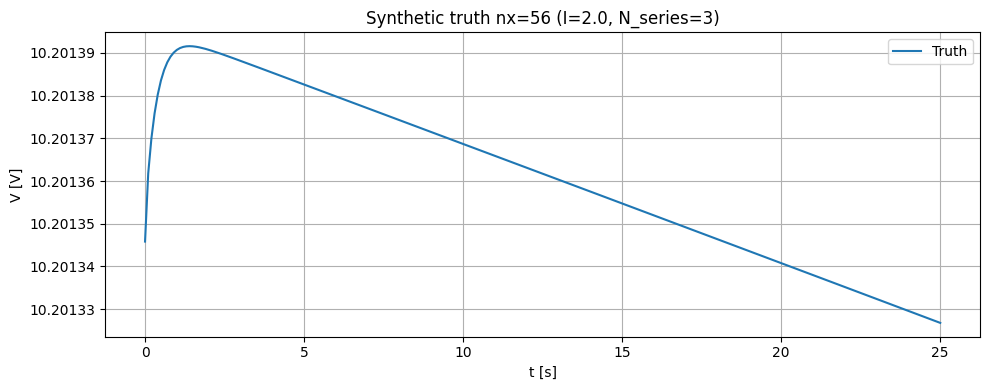

[stage2 warm] prefit...
[stage2 warm] prefit max|err|: 0.26969367139591327
[stage2 warm] fit...


  0%|                        |

Solving NLP with Adam (60 optimization variables) ...


100%|████████████████████████|
    f =  11070602150803596.000000, f* =  11070602150803596.000000, |grad f| =  210433858024.835541, iter = 100


Solving NLP with L-BFGS (60 optimization variables) ...
L-BFGS-B done in 8 iterations.
[stage2 warm] theta_hat_raw: [  0.1104398   -0.09342094  -3.34628962 -13.91253715]


...

  0%|                        |

Solving NLP with Adam (66 optimization variables) ...


100%|████████████████████████|
    f =  12300563112055692.000000, f* =  12300563112055692.000000, |grad f| =  221815807480.494629, iter = 200


Solving NLP with L-BFGS (66 optimization variables) ...
L-BFGS-B done in 14 iterations.
[stage4] trial 9 done. best_mse=4.13564e-10
[stage4] checkpoint saved: outputs_generated\stage4_trials_partial.csv

=== Stage 4 summary ===
{'mode': 'locked', 'total_configs': 10, 'runs_completed': 10, 'best_mse': 4.1356414095043725e-10, 'best_post_max': 3.997298763813717e-05}


,mode,trial,x0trial,ok_run,pre_max,post_max,mse,wall_s,err,Gamma_p,Gamma_n,K_e,R0,sDn,sDp,sDe,gn,gp,ge
0,locked,9,0,1,0.094128,0.000040,4.135641e-10,350.524849,,1.497984e+12,1.025345e-09,0.018933,1.045843e-06,1.160063,1.991826,1.338597,2.185532,0.428337,1.128647
1,locked,1,0,1,0.096106,0.000040,4.203185e-10,307.678412,,1.491678e+12,1.025171e-09,0.050779,3.973652e-07,0.739703,1.041074,1.288190,1.079494,0.883937,0.635082
2,locked,6,0,1,0.095310,0.000042,4.409503e-10,321.285340,,7.456308e+14,1.025244e-09,0.011940,7.045907e-07,1.145179,0.891058,1.055338,0.726089,0.443273,1.975609
3,locked,8,0,1,0.098489,0.000039,4.462547e-10,218.179645,,9.138149e+08,1.025030e-09,0.021850,6.342398e-07,1.439244,0.972605,0.748510,1.023726,0.479153,1.190390
4,locked,3,0,1,0.125985,0.000057,4.651476e-10,235.945828,,4.641910e+03,1.024594e-09,0.053081,5.679689e-07,0.569041,1.072587,0.794076,0.761930,1.143263,0.715914
5,locked,4,0,1,0.096722,0.000129,5.667221e-10,371.515406,,3.140944e+10,1.024166e-09,0.095908,1.047129e-06,1.043602,0.984210,1.281460,0.778741,4.344589,1.259870
6,locked,0,0,1,0.099251,0.000171,7.361982e-10,228.535958,,1.909563e+09,1.023748e-09,0.056544,7.942608e-07,1.324626,2.080251,0.993652,1.682131,0.876875,2.130852
7,locked,2,0,1,0.101576,0.000126,7.764101e-10,120.669025,,1.876433e+08,1.024147e-09,0.034153,2.561707e-07,1.036510,1.574786,0.543603,0.659880,0.604294,1.483223
8,locked,5,0,1,0.103889,0.000165,8.198854e-10,196.466374,,2.366044e+08,1.023810e-09,0.036902,9.295378e-07,0.579710,0.960942,0.741833,0.650289,0.441867,2.370297
9,locked,7,0,1,0.096941,0.000127,9.102856e-10,120.072416,,7.769447e+10,1.024152e-09,0.036122,4.856341e-07,0.691924,1.990170,0.427405,1.910923,1.245895,1.125345


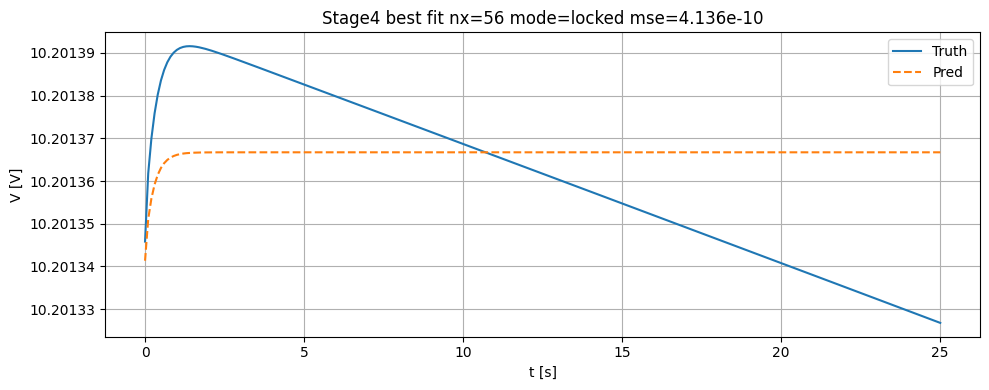

[run] done.


In [12]:
# -------- notebook parameters --------
outdir = "outputs_generated"
I_const = 2.0
t_end = 25.0
dt = 0.1
theta_n0 = 0.8
theta_p0 = 0.4
ce0 = 0.0
N_series = 3

use_v0 = False
warm_adam = 100
warm_lbfgs = 20

mode = "locked"     # "locked" or "free"
n_trials = 10       # start small in notebook; increase later
x0_trials = 4
seed = 0
# ------------------------------------

os.makedirs(outdir, exist_ok=True)

CFG = Config()
CFG.N_series = int(N_series)

idx = make_idx(CFG)
print("[run] nx =", idx["nx"], "(Nn,Np,Ne) =", (idx["Nn"], idx["Np"], idx["Ne"]))

# generate synthetic truth
t_np, U_np, X_truth, Y_np, idx2 = generate_discharge_data(
    CFG,
    I_const=float(I_const),
    sim_t_end=float(t_end),
    sim_dt=float(dt),
    theta_n0=float(theta_n0),
    theta_p0=float(theta_p0),
    ce0=float(ce0),
)

# show truth inline
voltage_plot_inline(
    t_np, Y_np, None,
    title=f"Synthetic truth nx={idx2['nx']} (I={I_const}, N_series={N_series})"
)

# warmstart stage2
theta_center_raw = fit_stage2_warmstart(
    CFG, idx2, t_np, U_np, Y_np,
    use_v0=bool(use_v0),
    adam_epochs=int(warm_adam),
    lbfgs_epochs=int(warm_lbfgs),
)

# stage4 multistart
best, df_trials, summary = stage4_multistart(
    CFG, idx2, t_np, U_np, Y_np,
    use_v0=bool(use_v0),
    theta_center_raw=theta_center_raw,
    X_truth=X_truth,
    mode=str(mode).lower(),
    n_trials=int(n_trials),
    x0_trials=int(x0_trials),
    seed=int(seed),
    outdir=str(outdir),
)

display(df_trials.head(10))

# show best fit inline
if best is not None:
    voltage_plot_inline(
        t_np, Y_np, best["Yhat"],
        title=f"Stage4 best fit nx={idx2['nx']} mode={best['mode']} mse={best['metrics']['mse']:.3e}"
    )

print("[run] done.")


In [14]:
%matplotlib inline

import os
import json
import time
from dataclasses import dataclass
from typing import Tuple, Dict, Any, Optional, List

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display

import control as ct
from scipy.linalg import block_diag

import jax
import jax.numpy as jnp
import diffrax
from jax_sysid.models import CTModel


In [15]:
def voltage_plot_inline(
    t: np.ndarray,
    y: np.ndarray,
    yhat: Optional[np.ndarray] = None,
    title: str = "Voltage",
):
    """Plot voltage inline in notebook."""
    plt.figure(figsize=(10, 4))
    plt.plot(t, y[:, 0], label="Truth")
    if yhat is not None:
        plt.plot(t, yhat[:, 0], "--", label="Pred")
    plt.grid(True)
    plt.legend()
    plt.xlabel("t [s]")
    plt.ylabel("V [V]")
    plt.title(title)
    ax = plt.gca()
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter(useOffset=False))
    ax.ticklabel_format(axis="y", style="plain", useOffset=False)
    plt.tight_layout()
    plt.show()


def save_voltage_plot(
    path: str,
    t: np.ndarray,
    y: np.ndarray,
    yhat: Optional[np.ndarray] = None,
    title: str = "Voltage",
):
    """Save voltage plot to file (png)."""
    plt.figure(figsize=(10, 4))
    plt.plot(t, y[:, 0], label="Truth")
    if yhat is not None:
        plt.plot(t, yhat[:, 0], "--", label="Pred")
    plt.grid(True)
    plt.legend()
    plt.xlabel("t [s]")
    plt.ylabel("V [V]")
    plt.title(title)
    ax = plt.gca()
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter(useOffset=False))
    ax.ticklabel_format(axis="y", style="plain", useOffset=False)
    plt.tight_layout()
    plt.savefig(path, dpi=200)
    plt.close()
    

# =========================================================
# Config
# =========================================================
@dataclass
class Config:
    # Physical constants
    R: float = 8.314462618
    F: float = 96485.33212
    T: float = 298.15
    T_ref: float = 298.15

    # Geometry
    L1: float = 25e-6
    L2: float = 20e-6
    L3: float = 25e-6
    Rn: float = 5e-6
    Rp: float = 5e-6
    A: float = 1.0

    # Transport
    Dn: float = 1e-14
    Dp: float = 1e-14
    De: float = 7.23e-10
    eps: float = 0.30

    # Effective conductivities for R_el
    kappa_n_eff: float = 1.0
    kappa_s_eff: float = 1.0
    kappa_p_eff: float = 1.0

    # Kinetics / active surface
    a_s_n: float = 1.0e6
    a_s_p: float = 1.0e6

    # Capacity-scale (stoichiometries)
    csn_max: float = 3.1e4
    csp_max: float = 3.1e4

    # Electrolyte & electrical
    ce0: float = 1000.0
    t_plus: float = 0.38
    k_f: float = 1.0
    R_ohm: float = 0.0
    use_dynamic_film: bool = False
    Rf: float = 0.0
    L_sei: float = 0.0
    kappa_sei: float = 1.0

    # Flags & conventions
    ce_is_deviation: bool = True
    discharge_positive: bool = True
    ln_orientation: str = "right_over_left"
    eta_mode: str = "diff"

    # Numerical guards / stability
    theta_guard: float = 1e-3
    bv_scale: float = 0.7
    N_series: int = 3

    # Discretization sizes (56 = 16 + 16 + 24)
    Nn: int = 16
    Np: int = 16
    Ne_n: int = 8
    Ne_s: int = 8
    Ne_p: int = 8


# =========================================================
# OCVs
# =========================================================
def ocp_p(xp: np.ndarray) -> np.ndarray:
    x = np.clip(xp, 1e-9, 1 - 1e-9)
    return 4.15 - 0.12 * np.tanh((x - 0.60) / 0.08)

def ocp_n(xn: np.ndarray) -> np.ndarray:
    x = np.clip(xn, 1e-9, 1 - 1e-9)
    return 0.10 + 0.80 * (1.0 / (1.0 + np.exp(-(x - 0.50) / 0.04)))


# =========================================================
# Dynamic index map
# =========================================================
def make_idx(cfg: Config) -> Dict[str, Any]:
    Nn = int(cfg.Nn)
    Np = int(cfg.Np)
    Ne = int(cfg.Ne_n + cfg.Ne_s + cfg.Ne_p)
    off_cp = Nn
    off_ce = Nn + Np
    return dict(
        Nn=Nn, Np=Np, Ne=Ne, nx=Nn + Np + Ne,
        cn=slice(0, Nn),
        cp=slice(off_cp, off_cp + Np),
        ce=slice(off_ce, off_ce + Ne),
        cn_surf=Nn - 1,
        cp_surf=off_cp + (Np - 1),
        ce_left=off_ce + 0,
        ce_right=off_ce + (Ne - 1),
    )


# =========================================================
# Spherical FVM for solid diffusion
# =========================================================
def build_solid_fvm_spherical(N: int, D: float, R: float) -> np.ndarray:
    if N < 2:
        raise ValueError("N must be >= 2")

    r_f = np.linspace(0.0, R, N + 1, dtype=np.float64)
    r_c = 0.5 * (r_f[:-1] + r_f[1:])

    V = (r_f[1:]**3 - r_f[:-1]**3) / 3.0
    A_face = r_f**2

    A = np.zeros((N, N), dtype=np.float64)

    for i_face in range(1, N):
        Af = A_face[i_face]
        dr = r_c[i_face] - r_c[i_face - 1]
        G = D * Af / dr

        iL = i_face - 1
        iR = i_face

        A[iL, iL] -= G / V[iL]
        A[iL, iR] += G / V[iL]
        A[iR, iR] -= G / V[iR]
        A[iR, iL] += G / V[iR]

    return A


def build_solid_input_spherical(N: int, R: float, cfg: Config, electrode: str) -> np.ndarray:
    r_f = np.linspace(0.0, R, N + 1, dtype=np.float64)
    V_last = (r_f[-1]**3 - r_f[-2]**3) / 3.0
    A_R = r_f[-1]**2
    surf_to_state = A_R / V_last

    if electrode == "n":
        I_to_j = 1.0 / (cfg.F * cfg.a_s_n * cfg.A * cfg.L1)
        sign = -1.0
        Ieff_sign = +1.0 if cfg.discharge_positive else -1.0
        coef = surf_to_state * sign * Ieff_sign * I_to_j
    elif electrode == "p":
        I_to_j = 1.0 / (cfg.F * cfg.a_s_p * cfg.A * cfg.L3)
        sign = +1.0
        Ieff_sign = +1.0 if cfg.discharge_positive else -1.0
        coef = surf_to_state * sign * Ieff_sign * I_to_j
    else:
        raise ValueError("electrode must be 'n' or 'p'")

    b = np.zeros((N, 1), dtype=np.float64)
    b[-1, 0] = coef
    return b


# =========================================================
# Electrolyte diffusion (unchanged)
# =========================================================
def build_electrolyte_1d(Nn: int, Ns: int, Np: int, cfg: Config) -> Tuple[np.ndarray, np.ndarray]:
    Ne = Nn + Ns + Np
    K = cfg.De / cfg.eps

    Ln, Ls, Lp = cfg.L1, cfg.L2, cfg.L3
    dx_n = Ln / Nn
    dx_s = Ls / Ns
    dx_p = Lp / Np

    A = np.zeros((Ne, Ne), dtype=np.float64)

    def dx(i: int) -> float:
        if i < Nn:
            return dx_n
        if i < Nn + Ns:
            return dx_s
        return dx_p

    for i in range(Ne):
        if i > 0:
            dxL = dx(i - 1)
            dxi = dx(i)
            wL = K / (0.5 * (dxL + dxi) ** 2)
            A[i, i] -= wL
            A[i, i - 1] += wL
        if i < Ne - 1:
            dxi = dx(i)
            dxR = dx(i + 1)
            wR = K / (0.5 * (dxi + dxR) ** 2)
            A[i, i] -= wR
            A[i, i + 1] += wR

    b = np.zeros((Ne, 1), dtype=np.float64)
    sign_left = -1.0 if cfg.discharge_positive else +1.0
    sign_right = +1.0 if cfg.discharge_positive else -1.0

    s1 = sign_left * (1.0 - cfg.t_plus) / (cfg.F * cfg.A * cfg.L1 * cfg.eps)
    s3 = sign_right * (1.0 - cfg.t_plus) / (cfg.F * cfg.A * cfg.L3 * cfg.eps)

    b[0, 0] = s1
    if Nn > 1:
        b[1, 0] = s1
    b[-1, 0] = s3
    if Np > 1:
        b[-2, 0] = s3

    return A, b


# =========================================================
# Assemble system
# =========================================================
def assemble_system(cfg: Config):
    idx = make_idx(cfg)

    An = build_solid_fvm_spherical(idx["Nn"], cfg.Dn, cfg.Rn)
    Ap = build_solid_fvm_spherical(idx["Np"], cfg.Dp, cfg.Rp)
    Bn = build_solid_input_spherical(idx["Nn"], cfg.Rn, cfg, electrode="n")
    Bp = build_solid_input_spherical(idx["Np"], cfg.Rp, cfg, electrode="p")

    Ae, Be = build_electrolyte_1d(cfg.Ne_n, cfg.Ne_s, cfg.Ne_p, cfg)

    Aglob = block_diag(An, Ap, Ae)
    Bglob = np.vstack([Bn, Bp, Be])

    state_names = (
        [f"cn{i}" for i in range(1, idx["Nn"] + 1)]
        + [f"cp{i}" for i in range(1, idx["Np"] + 1)]
        + [f"ce{i}" for i in range(1, idx["Ne"] + 1)]
    )

    S = ct.ss(Aglob, Bglob, np.eye(Aglob.shape[0]), np.zeros((Aglob.shape[0], 1)))
    blocks = (An, Ap, Ae, Bn, Bp, Be)
    return S, Aglob, Bglob, blocks, state_names, idx


def make_x0(cfg: Config, idx: Dict[str, Any], theta_n0=0.8, theta_p0=0.4, ce0=0.0):
    x0 = np.zeros(idx["nx"], dtype=np.float64)
    x0[idx["cn"]] = float(theta_n0) * cfg.csn_max
    x0[idx["cp"]] = float(theta_p0) * cfg.csp_max
    x0[idx["ce"]] = float(ce0)
    return x0


# =========================================================
# Voltage terms
# =========================================================
def electrolyte_resistance(cfg: Config) -> float:
    return (cfg.L1 / cfg.kappa_n_eff + 2.0 * cfg.L2 / cfg.kappa_s_eff + cfg.L3 / cfg.kappa_p_eff) / (2.0 * cfg.A)

def film_resistance(cfg: Config) -> float:
    if cfg.use_dynamic_film and cfg.L_sei > 0.0:
        return cfg.L_sei / (cfg.kappa_sei * cfg.a_s_n * cfg.A * cfg.L1)
    return cfg.Rf


# =========================================================
# Synthetic truth generator
# =========================================================
def terminal_voltage_truth(x: np.ndarray, cfg: Config, idx: Dict[str, Any], I: float) -> float:
    xp = np.clip(x[idx["cp_surf"]] / cfg.csp_max, 1e-9, 1 - 1e-9)
    xn = np.clip(x[idx["cn_surf"]] / cfg.csn_max, 1e-9, 1 - 1e-9)
    Up = float(ocp_p(np.array([xp]))[0])
    Un = float(ocp_n(np.array([xn]))[0])

    ceL_raw = float(x[idx["ce_left"]])
    ceR_raw = float(x[idx["ce_right"]])
    ceL = (cfg.ce0 + ceL_raw) if cfg.ce_is_deviation else ceL_raw
    ceR = (cfg.ce0 + ceR_raw) if cfg.ce_is_deviation else ceR_raw
    ceL = max(ceL, 1e-12)
    ceR = max(ceR, 1e-12)

    kappa = (2.0 * cfg.R * cfg.T / cfg.F)
    eta_combo = cfg.bv_scale * kappa * np.arcsinh(I / (2.0 * 1.0))

    ln_arg = (ceR / ceL) if (cfg.ln_orientation == "right_over_left") else (ceL / ceR)
    Ke_phys = (2.0 * cfg.R * cfg.T / cfg.F) * (1.0 - cfg.t_plus) * cfg.k_f
    dphi_e = Ke_phys * np.log(max(ln_arg, 1e-12))

    ohmic = -I * (cfg.R_ohm + electrolyte_resistance(cfg) + film_resistance(cfg))
    V_cell = (Up - Un) + eta_combo + dphi_e + ohmic
    return float(cfg.N_series * V_cell)


def battery_update(t, x, u, params):
    A = params["A"]; B = params["B"]
    if u is None or (hasattr(u, "size") and u.size == 0):
        I = float(params["I_const"])
    else:
        I = float(np.asarray(u).reshape(-1)[0])
    return A @ x + B[:, 0] * I


def battery_output(t, x, u, params):
    cfg = params["cfg"]
    idx = params["idx"]
    if u is None or (hasattr(u, "size") and u.size == 0):
        I = float(params["I_const"])
    else:
        I = float(np.asarray(u).reshape(-1)[0])
    V = terminal_voltage_truth(x, cfg, idx, I=I)
    return np.hstack([x, V])


def generate_discharge_data(
    cfg: Config,
    *,
    I_const: float,
    sim_t_end: float,
    sim_dt: float,
    theta_n0: float,
    theta_p0: float,
    ce0: float,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, Dict[str, Any]]:
    T = np.arange(0.0, sim_t_end + sim_dt, sim_dt)

    _, A, B, _, state_names, idx = assemble_system(cfg)
    nl_params = dict(A=A, B=B, cfg=cfg, idx=idx, I_const=float(I_const))

    battery_nl = ct.nlsys(
        battery_update, battery_output,
        name="battery_synth",
        params=nl_params,
        states=state_names,
        outputs=state_names + ["V"],
        inputs=0,
    )

    x0 = make_x0(cfg, idx, theta_n0=theta_n0, theta_p0=theta_p0, ce0=ce0)
    resp = ct.input_output_response(battery_nl, T, 0, X0=x0)

    X = resp.states.T
    Y_full = resp.outputs.T
    V = Y_full[:, -1:].copy()
    U = np.full((len(T), 1), float(I_const), dtype=np.float64)

    return T.astype(np.float64), U.astype(np.float64), X.astype(np.float64), V.astype(np.float64), idx


# =========================================================
# JAX models (Stage2 + Stage4)
# =========================================================
def build_stage2_and_stage4_models(cfg: Config, idx: Dict[str, Any], theta_guard: float, use_v0: bool):
    jax.config.update("jax_platform_name", "cpu")
    jax.config.update("jax_enable_x64", True)
    DTYPE = jnp.float64

    _, A_np, B_np, (An_np, Ap_np, Ae_np, Bn_np, Bp_np, Be_np), _, _ = assemble_system(cfg)
    A_fix = jnp.array(A_np, dtype=DTYPE)
    B_fix = jnp.array(B_np, dtype=DTYPE)

    An0 = jnp.array(An_np, dtype=DTYPE)
    Ap0 = jnp.array(Ap_np, dtype=DTYPE)
    Ae0 = jnp.array(Ae_np, dtype=DTYPE)
    Bn0 = jnp.array(Bn_np, dtype=DTYPE)
    Bp0 = jnp.array(Bp_np, dtype=DTYPE)
    Be0 = jnp.array(Be_np, dtype=DTYPE)

    R_fixed = float(cfg.R_ohm + electrolyte_resistance(cfg) + film_resistance(cfg))

    @jax.jit
    def ocp_p_jax(xp):
        xp = jnp.clip(xp, 1e-9, 1 - 1e-9)
        return 4.15 - 0.12 * jnp.tanh((xp - 0.60) / 0.08)

    @jax.jit
    def ocp_n_jax(xn):
        xn = jnp.clip(xn, 1e-9, 1 - 1e-9)
        return 0.10 + 0.80 * (1.0 / (1.0 + jnp.exp(-(xn - 0.50) / 0.04)))

    def theta_map(raw_theta: jnp.ndarray) -> dict:
        Gamma_p = jnp.exp(raw_theta[0])
        Gamma_n = jnp.exp(raw_theta[1])
        K_e     = jnp.exp(raw_theta[2])
        R0      = jnp.exp(raw_theta[3])
        V0      = raw_theta[4] if use_v0 else DTYPE(0.0)
        return dict(
            csn_max=DTYPE(cfg.csn_max),
            csp_max=DTYPE(cfg.csp_max),
            Gamma_p=Gamma_p,
            Gamma_n=Gamma_n,
            K_e=K_e,
            R0=R0,
            V0=V0,
        )

    def voltage_from_params(x, I, p: dict):
        xp = jnp.clip(x[idx["cp_surf"]] / p["csp_max"], 1e-9, 1 - 1e-9)
        xn = jnp.clip(x[idx["cn_surf"]] / p["csn_max"], 1e-9, 1 - 1e-9)

        Up = ocp_p_jax(xp)
        Un = ocp_n_jax(xn)

        ceL_raw = x[idx["ce_left"]]
        ceR_raw = x[idx["ce_right"]]
        ceL = (DTYPE(cfg.ce0) + ceL_raw) if cfg.ce_is_deviation else ceL_raw
        ceR = (DTYPE(cfg.ce0) + ceR_raw) if cfg.ce_is_deviation else ceR_raw
        ceL = jnp.maximum(ceL, 1e-12)
        ceR = jnp.maximum(ceR, 1e-12)
        ce_avg = jnp.clip(0.5 * (ceL + ceR), 1e-12, 1e12)

        xp_eff = jnp.clip(xp, theta_guard, 1.0 - theta_guard)
        xn_eff = jnp.clip(xn, theta_guard, 1.0 - theta_guard)

        denom_p = p["Gamma_p"] * jnp.sqrt(ce_avg) * jnp.sqrt(xp_eff * (1 - xp_eff)) + 1e-18
        denom_n = p["Gamma_n"] * jnp.sqrt(ce_avg) * jnp.sqrt(xn_eff * (1 - xn_eff)) + 1e-18

        kappa = (2.0 * DTYPE(cfg.R) * DTYPE(cfg.T) / DTYPE(cfg.F))
        eta_p = DTYPE(cfg.bv_scale) * kappa * jnp.arcsinh(I / (2.0 * denom_p))
        eta_n = DTYPE(cfg.bv_scale) * kappa * jnp.arcsinh(I / (2.0 * denom_n))
        eta_combo = (eta_p - eta_n) if (cfg.eta_mode == "diff") else (eta_p + eta_n)

        ln_arg = (ceR / ceL) if (cfg.ln_orientation == "right_over_left") else (ceL / ceR)
        dphi_e = p["K_e"] * jnp.log(jnp.maximum(ln_arg, 1e-12))

        ohmic = -I * (DTYPE(R_fixed) + p["R0"])
        V_cell = (Up - Un) + eta_combo + dphi_e + ohmic
        V = DTYPE(cfg.N_series) * V_cell + p["V0"]
        return V

    @jax.jit
    def state_fcn_stage2(x, u, t, params):
        I = u[0]
        return A_fix @ x + (B_fix[:, 0] * I)

    @jax.jit
    def output_fcn_stage2(x, u, t, params):
        (raw_theta,) = params
        p = theta_map(raw_theta)
        I = u[0]
        V = voltage_from_params(x, I, p)
        return jnp.array([V], dtype=DTYPE)

    def ab_map(raw_ab: jnp.ndarray) -> dict:
        return dict(
            sDn=jnp.exp(raw_ab[0]),
            sDp=jnp.exp(raw_ab[1]),
            sDe=jnp.exp(raw_ab[2]),
            gn=jnp.exp(raw_ab[3]),
            gp=jnp.exp(raw_ab[4]),
            ge=jnp.exp(raw_ab[5]),
        )

    def build_AB_from_ab(raw_ab: jnp.ndarray):
        ab = ab_map(raw_ab)
        A = jnp.block([
            [ab["sDn"] * An0,               jnp.zeros((An0.shape[0], Ap0.shape[1]), dtype=DTYPE), jnp.zeros((An0.shape[0], Ae0.shape[1]), dtype=DTYPE)],
            [jnp.zeros((Ap0.shape[0], An0.shape[1]), dtype=DTYPE), ab["sDp"] * Ap0,               jnp.zeros((Ap0.shape[0], Ae0.shape[1]), dtype=DTYPE)],
            [jnp.zeros((Ae0.shape[0], An0.shape[1]), dtype=DTYPE), jnp.zeros((Ae0.shape[0], Ap0.shape[1]), dtype=DTYPE), ab["sDe"] * Ae0],
        ])
        B = jnp.concatenate([ab["gn"] * Bn0, ab["gp"] * Bp0, ab["ge"] * Be0], axis=0)
        return A, B

    theta_len = 5 if use_v0 else 4

    def unpack_stage4(raw: jnp.ndarray):
        raw_theta = raw[:theta_len]
        raw_ab = raw[theta_len:theta_len + 6]
        return raw_theta, raw_ab

    @jax.jit
    def state_fcn_stage4(x, u, t, params):
        (raw,) = params
        _, raw_ab = unpack_stage4(raw)
        A, B = build_AB_from_ab(raw_ab)
        I = u[0]
        return A @ x + (B[:, 0] * I)

    @jax.jit
    def output_fcn_stage4(x, u, t, params):
        (raw,) = params
        raw_theta, _ = unpack_stage4(raw)
        p = theta_map(raw_theta)
        I = u[0]
        V = voltage_from_params(x, I, p)
        return jnp.array([V], dtype=DTYPE)

    return dict(
        DTYPE=DTYPE,
        theta_map=theta_map,
        ab_map=ab_map,
        state_fcn_stage2=state_fcn_stage2,
        output_fcn_stage2=output_fcn_stage2,
        state_fcn_stage4=state_fcn_stage4,
        output_fcn_stage4=output_fcn_stage4,
        R_fixed=R_fixed,
        theta_len=theta_len,
        nx=int(idx["nx"]),
    )


def fit_stage2_warmstart(
    cfg: Config,
    idx: Dict[str, Any],
    t_np: np.ndarray,
    U_np: np.ndarray,
    Y_np: np.ndarray,
    *,
    use_v0: bool,
    dt0_div: float = 50.0,
    adam_epochs: int = 100,
    lbfgs_epochs: int = 20,
    adam_eta: float = 1e-3,
    rtol: float = 1e-6,
    atol: float = 1e-9,
    max_steps: int = 2_000_000,
) -> np.ndarray:
    parts = build_stage2_and_stage4_models(cfg, idx, theta_guard=cfg.theta_guard, use_v0=use_v0)

    Ke_phys = (2.0 * cfg.R * cfg.T / cfg.F) * (1.0 - cfg.t_plus) * cfg.k_f
    if use_v0:
        theta0_raw = np.array([np.log(1.0), np.log(1.0), np.log(Ke_phys), np.log(1e-6), 0.0], dtype=np.float64)
    else:
        theta0_raw = np.array([np.log(1.0), np.log(1.0), np.log(Ke_phys), np.log(1e-6)], dtype=np.float64)

    x0_init = make_x0(cfg, idx, theta_n0=0.6, theta_p0=0.6, ce0=0.0)

    nx = parts["nx"]
    m2 = CTModel(nx, 1, 1, state_fcn=parts["state_fcn_stage2"], output_fcn=parts["output_fcn_stage2"])
    m2.init(params=[theta0_raw], x0=np.array(x0_init, dtype=np.float64))

    rho_x0 = 1e6
    rho_th = 1e-8
    try:
        m2.loss(rho_x0=rho_x0, rho_th=rho_th, xsat=1e9)
    except TypeError:
        m2.loss(rho_x0=rho_x0, rho_th=rho_th)

    m2.optimization(adam_epochs=adam_epochs, lbfgs_epochs=lbfgs_epochs, adam_eta=adam_eta)

    dt0 = float(t_np[1] - t_np[0]) / float(dt0_div)
    m2.integration_options(
        ode_solver=diffrax.Tsit5(),
        dt0=dt0,
        max_steps=int(max_steps),
        stepsize_controller=diffrax.PIDController(rtol=rtol, atol=atol),
    )

    print("[stage2 warm] prefit...")
    Y0, _ = m2.predict(m2.x0, U_np, t_np)
    print("[stage2 warm] prefit max|err|:", float(np.max(np.abs(np.asarray(Y0) - Y_np))))

    print("[stage2 warm] fit...")
    m2.fit(Y_np, U_np, t_np)

    theta_hat = np.asarray(m2.params[0]).copy()
    print("[stage2 warm] theta_hat_raw:", theta_hat)
    return theta_hat


def stage4_multistart(
    cfg: Config,
    idx: Dict[str, Any],
    t_np: np.ndarray,
    U_np: np.ndarray,
    Y_np: np.ndarray,
    *,
    use_v0: bool,
    theta_center_raw: np.ndarray,
    X_truth: Optional[np.ndarray],
    mode: str,
    n_trials: int = 50,
    x0_trials: int = 8,
    seed: int = 0,
    outdir: str = "outputs_generated",
    checkpoint_every: int = 1,
    ab_lo: float = 0.50,
    ab_hi: float = 2.00,
    theta_sigma: float = 0.50,
    x0_theta_lo: float = 0.05,
    x0_theta_hi: float = 0.95,
    x0_ce0: float = 0.0,
    rho_x0_locked: float = 1e6,
    rho_x0_free: float = 0.0,
    rho_th: float = 1e-8,
    adam_epochs: int = 200,
    lbfgs_epochs: int = 60,
    adam_eta: float = 1e-3,
    dt0_div: float = 25.0,
    max_steps: int = 5_000_000,
    rtol: float = 1e-6,
    atol: float = 1e-9,
) -> Tuple[Optional[Dict[str, Any]], pd.DataFrame, Dict[str, Any]]:
    parts = build_stage2_and_stage4_models(cfg, idx, theta_guard=cfg.theta_guard, use_v0=use_v0)
    DTYPE = parts["DTYPE"]
    theta_len = int(parts["theta_len"])
    nx = parts["nx"]

    os.makedirs(outdir, exist_ok=True)
    ckpt_csv = os.path.join(outdir, "stage4_trials_partial.csv")
    ckpt_best = os.path.join(outdir, "stage4_best_partial.json")

    rows: List[Dict[str, Any]] = []
    best: Optional[Dict[str, Any]] = None

    def unpack_stage4_np(raw: np.ndarray):
        raw_theta = jnp.array(raw[:theta_len], dtype=DTYPE)
        raw_ab = jnp.array(raw[theta_len:theta_len + 6], dtype=DTYPE)
        return raw_theta, raw_ab

    for i in range(int(n_trials)):
        rng = np.random.default_rng(seed + i)

        raw_theta0 = theta_center_raw + rng.normal(0.0, theta_sigma, size=(theta_len,))
        raw_ab0 = rng.uniform(np.log(ab_lo), np.log(ab_hi), size=(6,))
        raw0 = np.concatenate([raw_theta0, raw_ab0]).astype(np.float64)

        if mode == "locked":
            if X_truth is None:
                raise RuntimeError("mode='locked' requires X_truth (x0 = X_truth[0]).")
            x0_list = [np.array(X_truth[0], dtype=np.float64)]
            rho_x0 = float(rho_x0_locked)
        elif mode == "free":
            x0_list = []
            for _ in range(max(1, int(x0_trials))):
                tn0 = float(rng.uniform(x0_theta_lo, x0_theta_hi))
                tp0 = float(rng.uniform(x0_theta_lo, x0_theta_hi))
                x0_list.append(make_x0(cfg, idx, theta_n0=tn0, theta_p0=tp0, ce0=x0_ce0))
            rho_x0 = float(rho_x0_free)
        else:
            raise ValueError("mode must be 'locked' or 'free'")

        for j, x0_init in enumerate(x0_list):
            t_start_wall = time.time()
            try:
                m4 = CTModel(nx, 1, 1, state_fcn=parts["state_fcn_stage4"], output_fcn=parts["output_fcn_stage4"])
                m4.init(params=[raw0.astype(np.float64)], x0=np.array(x0_init, dtype=np.float64))

                try:
                    m4.loss(rho_x0=rho_x0, rho_th=rho_th, xsat=1e9)
                except TypeError:
                    m4.loss(rho_x0=rho_x0, rho_th=rho_th)

                m4.optimization(adam_epochs=adam_epochs, lbfgs_epochs=lbfgs_epochs, adam_eta=adam_eta)

                dt0 = float(t_np[1] - t_np[0]) / float(dt0_div)
                m4.integration_options(
                    ode_solver=diffrax.Tsit5(),
                    dt0=dt0,
                    max_steps=int(max_steps),
                    stepsize_controller=diffrax.PIDController(rtol=rtol, atol=atol),
                )

                Y0, _ = m4.predict(m4.x0, U_np, t_np)
                pre_max = float(np.max(np.abs(np.asarray(Y0) - Y_np)))

                m4.fit(Y_np, U_np, t_np)

                Yhat, _ = m4.predict(m4.x0, U_np, t_np)
                err = np.asarray(Yhat) - Y_np
                post_max = float(np.max(np.abs(err)))
                mse = float(np.mean(err**2))

                raw_final = np.asarray(m4.params[0]).copy()
                raw_theta_f, raw_ab_f = unpack_stage4_np(raw_final)
                p_f = parts["theta_map"](raw_theta_f)
                ab_f = parts["ab_map"](raw_ab_f)

                th_keys = ["Gamma_p", "Gamma_n", "K_e", "R0"] + (["V0"] if use_v0 else [])
                th = {k: float(p_f[k]) for k in th_keys}
                ab = {k: float(ab_f[k]) for k in ["sDn", "sDp", "sDe", "gn", "gp", "ge"]}

                ok = bool(np.isfinite(mse) and np.isfinite(post_max))
                errtxt = ""
            except Exception as e:
                ok = False
                pre_max = float("inf")
                post_max = float("inf")
                mse = float("inf")
                Yhat = None
                th = {}
                ab = {}
                raw_final = None
                errtxt = repr(e)

            wall = time.time() - t_start_wall
            row = dict(
                mode=mode, trial=int(i), x0trial=int(j),
                ok_run=int(ok), pre_max=float(pre_max), post_max=float(post_max),
                mse=float(mse), wall_s=float(wall), err=errtxt,
                **th, **ab,
            )
            rows.append(row)

            if ok and (best is None or mse < best["metrics"]["mse"]):
                best = dict(
                    Yhat=np.asarray(Yhat),
                    metrics=dict(pre_max=float(pre_max), post_max=float(post_max), mse=float(mse)),
                    theta=th, ab=ab,
                    x0=np.array(x0_init, dtype=np.float64),
                    raw_final=raw_final,
                    trial=int(i), x0trial=int(j), mode=mode,
                )

        print(f"[stage4] trial {i} done. best_mse={best['metrics']['mse'] if best else np.inf:.6g}")

        if checkpoint_every > 0 and ((i + 1) % checkpoint_every == 0):
            df_partial = pd.DataFrame(rows).sort_values("mse").reset_index(drop=True)
            df_partial.to_csv(ckpt_csv, index=False)
            if best is not None:
                best_to_save = dict(
                    mode=best["mode"],
                    trial=best["trial"],
                    x0trial=best["x0trial"],
                    metrics=best["metrics"],
                    theta=best["theta"],
                    ab=best["ab"],
                    x0=best["x0"].tolist(),
                )
                with open(ckpt_best, "w", encoding="utf-8") as f:
                    json.dump(best_to_save, f, indent=2)
            print(f"[stage4] checkpoint saved: {ckpt_csv}")

    df = pd.DataFrame(rows).sort_values("mse").reset_index(drop=True)
    summary = dict(
        mode=mode,
        total_configs=int(len(df)),
        runs_completed=int(df["ok_run"].sum()) if len(df) else 0,
        best_mse=float(df.iloc[0]["mse"]) if len(df) else float("inf"),
        best_post_max=float(df.iloc[0]["post_max"]) if len(df) else float("inf"),
    )
    print("\n=== Stage 4 summary ===")
    print(summary)
    return best, df, summary


[run] nx = 56 (Nn,Np,Ne) = (16, 16, 24)


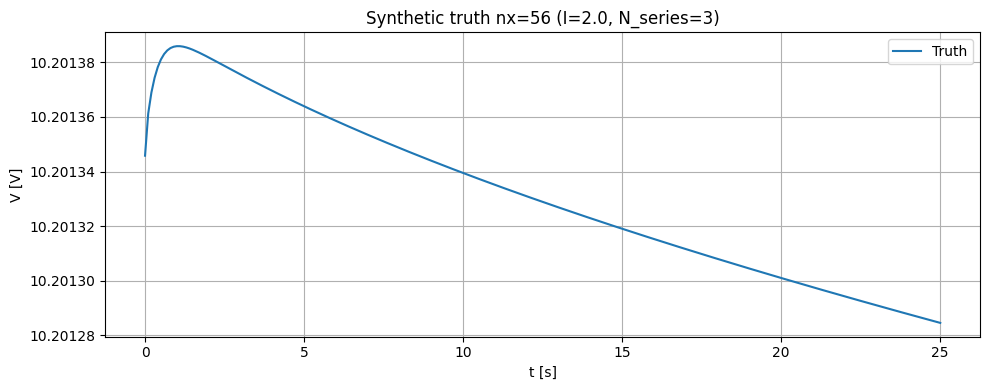

[stage2 warm] prefit...
[stage2 warm] prefit max|err|: 0.2697437296731433
[stage2 warm] fit...


  0%|                        |

Solving NLP with Adam (60 optimization variables) ...


100%|████████████████████████|
    f =  11070602150803596.000000, f* =  11070602150803596.000000, |grad f| =  210433858024.835541, iter = 100


Solving NLP with L-BFGS (60 optimization variables) ...
L-BFGS-B done in 7 iterations.
[stage2 warm] theta_hat_raw: [  0.13011179  -0.11305446  -3.34630458 -13.91253576]


...

  0%|                        |

Solving NLP with Adam (66 optimization variables) ...


100%|████████████████████████|
    f =  12300563112055692.000000, f* =  12300563112055692.000000, |grad f| =  221815807480.493713, iter = 200


Solving NLP with L-BFGS (66 optimization variables) ...
L-BFGS-B done in 18 iterations.
[stage4] trial 24 done. best_mse=7.16528e-10
[stage4] checkpoint saved: outputs_generated\stage4_trials_partial.csv

=== Stage 4 summary ===
{'mode': 'locked', 'total_configs': 25, 'runs_completed': 25, 'best_mse': 7.16527950301721e-10, 'best_post_max': 7.369281418334594e-05}


,mode,trial,x0trial,ok_run,pre_max,post_max,mse,wall_s,err,Gamma_p,Gamma_n,K_e,R0,sDn,sDp,sDe,gn,gp,ge
0,locked,3,0,1,0.126669,0.000074,7.165280e-10,187.455819,,3.258923e+03,1.024346e-09,0.053082,5.679603e-07,0.467423,0.746424,0.794060,0.763040,4.289069,0.715929
1,locked,14,0,1,0.106349,0.000053,9.593806e-10,415.511233,,3.308344e+06,1.024892e-09,0.019737,2.377854e-07,0.994804,1.294882,1.168384,1.653708,0.790008,1.361344
2,locked,22,0,1,0.100220,0.000051,9.605217e-10,482.482831,,8.101408e+08,1.024923e-09,0.022595,5.544469e-07,0.773946,2.376385,1.322759,1.952947,0.444315,1.328963
3,locked,9,0,1,0.094466,0.000053,9.608023e-10,325.670317,,9.138519e+11,1.025066e-09,0.018935,1.045798e-06,1.102355,2.151126,1.338455,2.189795,0.429021,1.128768
4,locked,24,0,1,0.100129,0.000063,9.721264e-10,486.413552,,1.711775e+07,1.024766e-09,0.024030,6.867633e-07,0.894270,0.582016,1.375790,0.691139,17.047356,1.903439
5,locked,1,0,1,0.096334,0.000053,9.770986e-10,316.757658,,7.097048e+11,1.024891e-09,0.050790,3.973289e-07,0.630182,0.650207,1.287888,1.081488,4.797753,0.635233
6,locked,17,0,1,0.099706,0.000060,9.947504e-10,248.998869,,6.095218e+07,1.024839e-09,0.032909,4.050757e-07,0.551004,0.386818,0.739178,1.431074,33.617296,0.625306
7,locked,6,0,1,0.095455,0.000054,9.972301e-10,316.398766,,2.620693e+14,1.024963e-09,0.011944,7.045537e-07,1.040863,0.957345,1.054936,0.727685,0.443843,1.976372
8,locked,18,0,1,0.104274,0.000079,1.033969e-09,334.589138,,1.332281e+08,1.024602e-09,0.060267,4.363193e-07,1.568329,1.322766,0.999441,1.362551,0.799224,0.723992
9,locked,8,0,1,0.099130,0.000065,1.036672e-09,222.570191,,7.815148e+08,1.024752e-09,0.021851,6.341820e-07,1.367287,1.040572,0.748451,1.025760,0.479797,1.190485


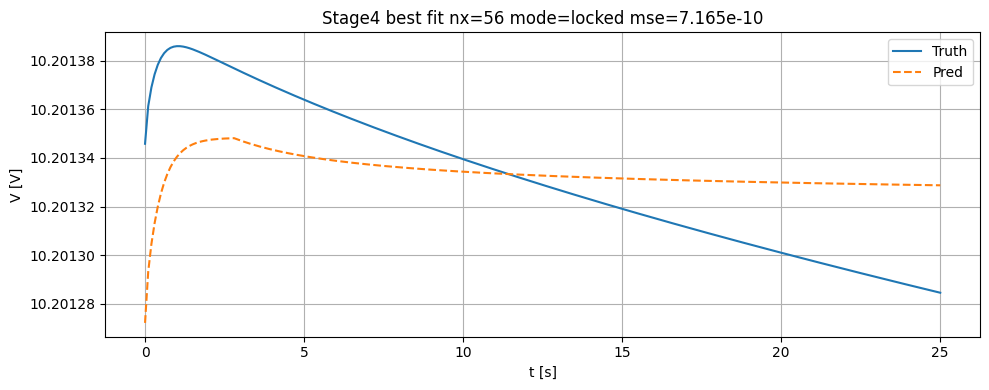

[run] done.


In [16]:
# -----------------------------
# Notebook run parameters
# -----------------------------
outdir = "outputs_generated"

# synthetic generation knobs
I_const  = 2.0
t_end    = 25.0
dt       = 0.1
theta_n0 = 0.8
theta_p0 = 0.4
ce0      = 0.0
N_series = 3

# stage2 warmstart knobs
use_v0    = False
warm_adam = 100
warm_lbfgs = 20

# stage4 knobs
mode     = "locked"   # "locked" or "free"
n_trials = 25
x0_trials = 8
seed     = 0

# -----------------------------
# Run
# -----------------------------
os.makedirs(outdir, exist_ok=True)

CFG = Config()
CFG.N_series = int(N_series)

idx = make_idx(CFG)
print("[run] nx =", idx["nx"], "(Nn,Np,Ne) =", (idx["Nn"], idx["Np"], idx["Ne"]))

t_np, U_np, X_truth, Y_np, idx2 = generate_discharge_data(
    CFG,
    I_const=float(I_const),
    sim_t_end=float(t_end),
    sim_dt=float(dt),
    theta_n0=float(theta_n0),
    theta_p0=float(theta_p0),
    ce0=float(ce0),
)

# show truth inline
voltage_plot_inline(
    t_np, Y_np, None,
    title=f"Synthetic truth nx={idx2['nx']} (I={I_const}, N_series={N_series})"
)

# also save truth
save_voltage_plot(
    os.path.join(outdir, "synthetic_voltage_truth.png"),
    t_np, Y_np, None,
    title=f"Synthetic truth nx={idx2['nx']} (I={I_const}, N_series={N_series})"
)

# warmstart stage2
theta_center_raw = fit_stage2_warmstart(
    CFG, idx2, t_np, U_np, Y_np,
    use_v0=bool(use_v0),
    adam_epochs=int(warm_adam),
    lbfgs_epochs=int(warm_lbfgs),
)

# stage4
best, df_trials, summary = stage4_multistart(
    CFG, idx2, t_np, U_np, Y_np,
    use_v0=bool(use_v0),
    theta_center_raw=theta_center_raw,
    X_truth=X_truth,
    mode=str(mode).lower(),
    n_trials=int(n_trials),
    x0_trials=int(x0_trials),
    seed=int(seed),
    outdir=str(outdir),
)

# show a table
display(df_trials.head(10))

# save outputs
df_trials.to_csv(os.path.join(outdir, "stage4_trials.csv"), index=False)
with open(os.path.join(outdir, "stage4_summary.json"), "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

if best is not None:
    with open(os.path.join(outdir, "stage4_best.json"), "w", encoding="utf-8") as f:
        json.dump(
            dict(
                mode=best["mode"], trial=best["trial"], x0trial=best["x0trial"],
                metrics=best["metrics"], theta=best["theta"], ab=best["ab"],
                x0=best["x0"].tolist()
            ),
            f, indent=2
        )

    # show best fit inline + save
    voltage_plot_inline(
        t_np, Y_np, best["Yhat"],
        title=f"Stage4 best fit nx={idx2['nx']} mode={best['mode']} mse={best['metrics']['mse']:.3e}"
    )
    save_voltage_plot(
        os.path.join(outdir, "stage4_best_fit.png"),
        t_np, Y_np, best["Yhat"],
        title=f"Stage4 best fit nx={idx2['nx']} mode={best['mode']}"
    )

print("[run] done.")
